# tACS Bandit Task Analyses

Analysis notebook for: *Examining the effects of theta-tACS over left DLPFC on reward-based learning across the adult lifespan*

This notebook implements all pre-registered analyses (H1.1, H1.2, H2.1, H2.2; https://osf.io/vhyz2) plus secondary and exploratory analyses. It reads trial-level behavioral data from the `tacs_bandit` repository, computes WSLS and Rescorla-Wagner parameters, and merges with REDCap-derived cognitive and demographic data.

## 0. Setup and Configuration

In [17]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize
from pathlib import Path

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')

# --- Path configuration ---
# Assumes notebook lives in tacs_bandit/code/
REPO_ROOT = Path('..').resolve()
DATA_DIR = REPO_ROOT / 'data' / 'bandit'
REDCAP_RF1_PATH = REPO_ROOT / 'data' / 'RF1SocialRewardProce-FullScoringFinishedS_DATA_LABELS_2025-12-10_1229.csv'
REDCAP_TACS_PATH = REPO_ROOT / 'data' / 'TACSBandit-TACSBandittestReport_DATA_LABELS_2026-02-27_1112.csv'

# --- Subject tracker ---
SUBJECT_INFO = {
    '10886': {'counterbalance': 'B'},
    '10998': {'counterbalance': 'B'},
    '11773': {'counterbalance': 'B'},
    '10656': {'counterbalance': 'A'}
}

# --- Task parameters ---
WIN_FRACTION = 0.75  # reward probability for the "good" option

print(f'Repository root: {REPO_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Subjects in tracker: {list(SUBJECT_INFO.keys())}')

Repository root: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit
Data directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/bandit
Subjects in tracker: ['10886', '10998', '11773', '10656']


## 1. Data Loading

Load all trial-level CSVs for each participant. When duplicate files exist for the same run (e.g., due to a false start), we keep only the latest file by timestamp. Pilot/test subjects are excluded.

In [20]:
def get_latest_run_files(subject_dir):
    """
    For a given subject directory, find all CSV files and return only the
    latest file for each run number (handles false starts/restarts).
    
    Returns dict: {run_number: filepath}
    """
    csv_files = sorted(glob.glob(str(subject_dir / '*.csv')))
    
    run_files = {}  # run_num -> list of (timestamp_str, filepath)
    for f in csv_files:
        fname = os.path.basename(f)
        # Parse run number from filename: sub-XXXXX_ses-1_run-XX_task-bandit_DATE.csv
        parts = fname.split('_')
        run_str = [p for p in parts if p.startswith('run-')]
        if not run_str:
            continue
        run_num = int(run_str[0].replace('run-', ''))
        
        # Use file modification time as tiebreaker (later = more recent)
        mtime = os.path.getmtime(f)
        
        if run_num not in run_files:
            run_files[run_num] = []
        run_files[run_num].append((mtime, f))
    
    # Keep only the latest file per run
    latest = {}
    for run_num, files in run_files.items():
        files.sort(key=lambda x: x[0])
        latest[run_num] = files[-1][1]  # last = most recent
        if len(files) > 1:
            print(f'  Run {run_num}: {len(files)} files found, using latest')
    
    return latest


def load_subject_data(subject_id, subject_dir):
    """
    Load and concatenate all runs for a single subject.
    Adds condition labels based on counterbalance order.
    """
    print(f'Loading sub-{subject_id}...')
    run_files = get_latest_run_files(subject_dir)
    
    if not run_files:
        print(f'  WARNING: No CSV files found')
        return None
    
    dfs = []
    for run_num in sorted(run_files.keys()):
        df = pd.read_csv(run_files[run_num])
        dfs.append(df)
        n_trials = len(df)
        n_missed = df['choice'].isna().sum()
        print(f'  Run {run_num}: {n_trials} trials, {n_missed} missed')
    
    data = pd.concat(dfs, ignore_index=True)
    
    # Add condition labels based on counterbalance order
    cb = SUBJECT_INFO.get(subject_id, {}).get('counterbalance', 'UNKNOWN')
    data['counterbalance'] = cb
    
    # Map runs to condition phases
    if cb == 'A':
        # A: active=2,3; sham=6,7
        condition_map = {1: 'baseline', 2: 'active', 3: 'active', 4: 'post',
                         5: 'baseline', 6: 'sham', 7: 'sham', 8: 'post'}
    elif cb == 'B':
        # B: sham=2,3; active=6,7
        condition_map = {1: 'baseline', 2: 'sham', 3: 'sham', 4: 'post',
                         5: 'baseline', 6: 'active', 7: 'active', 8: 'post'}
    else:
        condition_map = {}
        print(f'  WARNING: Unknown counterbalance "{cb}" for sub-{subject_id}')
    
    data['condition'] = data['run'].map(condition_map)
    data['subject_id'] = str(subject_id)
    
    return data


# --- Load all subjects ---
# Skip pilot/test subjects
EXCLUDE_PREFIXES = ['avi-pilot', 'p1001', '00002', '1122', '1432']

all_data = []
for sub_dir in sorted(DATA_DIR.iterdir()):
    if not sub_dir.is_dir():
        continue
    
    sub_id = sub_dir.name.replace('sub-', '')
    
    # Skip pilot subjects
    if any(sub_id.startswith(prefix) or sub_id == prefix for prefix in EXCLUDE_PREFIXES):
        print(f'Skipping pilot/test subject: sub-{sub_id}')
        continue
    
    # Skip subjects not in our tracker
    if sub_id not in SUBJECT_INFO:
        print(f'Skipping sub-{sub_id} (not in subject tracker)')
        continue
    
    df = load_subject_data(sub_id, sub_dir)
    if df is not None:
        all_data.append(df)

data = pd.concat(all_data, ignore_index=True)
print(f'\nLoaded {len(data)} total trials from {data["subject_id"].nunique()} subjects')

Skipping pilot/test subject: sub-00002
Loading sub-10656...
  Run 1: 70 trials, 4 missed
  Run 2: 77 trials, 0 missed
  Run 3: 74 trials, 0 missed
  Run 4: 74 trials, 0 missed
  Run 5: 76 trials, 0 missed
  Run 6: 76 trials, 0 missed
  Run 7: 77 trials, 0 missed
  Run 8: 76 trials, 0 missed
Loading sub-10886...
  Run 2: 2 files found, using latest
  Run 1: 74 trials, 4 missed
  Run 2: 75 trials, 0 missed
  Run 3: 75 trials, 0 missed
  Run 4: 75 trials, 0 missed
  Run 5: 75 trials, 0 missed
  Run 6: 76 trials, 0 missed
  Run 7: 76 trials, 0 missed
  Run 8: 76 trials, 0 missed
Loading sub-10998...
  Run 1: 70 trials, 2 missed
  Run 2: 70 trials, 4 missed
  Run 3: 75 trials, 1 missed
  Run 4: 76 trials, 0 missed
  Run 5: 77 trials, 0 missed
  Run 6: 75 trials, 0 missed
  Run 7: 76 trials, 0 missed
  Run 8: 77 trials, 0 missed
Skipping pilot/test subject: sub-1122
Loading sub-11773...
  Run 1: 70 trials, 1 missed
  Run 2: 73 trials, 1 missed
  Run 3: 77 trials, 1 missed
  Run 4: 79 trials,

## 2. Trial-Level Preprocessing

Compute trial-level variables needed for WSLS analysis: previous choice, previous outcome, and whether the participant stayed or shifted.

In [23]:
def preprocess_trials(df):
    """
    Add trial-level WSLS variables within each subject and run.
    Operates on the full dataset; groups by subject_id and run.
    """
    df = df.copy()
    
    # Previous trial's choice and reward (within each run)
    df['prev_choice'] = df.groupby(['subject_id', 'run'])['choice'].shift(1)
    df['prev_reward'] = df.groupby(['subject_id', 'run'])['reward'].shift(1)
    
    # Stay = same choice as previous trial
    df['stay'] = (df['choice'] == df['prev_choice']).astype(float)
    
    # Shift = different choice from previous trial
    df['shift'] = (df['choice'] != df['prev_choice']).astype(float)
    
    # Mark valid trials (not first trial in run, no missed responses on current or previous)
    df['valid_wsls'] = (
        df['prev_choice'].notna() & 
        df['choice'].notna() & 
        df['prev_reward'].notna()
    )
    
    return df

data = preprocess_trials(data)

# Quick sanity check
valid = data[data['valid_wsls']]
print(f'Valid WSLS trials: {len(valid)} / {len(data)} ({100*len(valid)/len(data):.1f}%)')
print(f'\nOverall stay|win rate: {valid[valid["prev_reward"]==True]["stay"].mean():.3f}')
print(f'Overall shift|lose rate: {valid[valid["prev_reward"]==False]["shift"].mean():.3f}')

Valid WSLS trials: 2355 / 2419 (97.4%)

Overall stay|win rate: 0.907
Overall shift|lose rate: 0.669


## 3. WSLS Parameter Computation

Compute p(stay|win) and p(shift|lose) for each subject, separately for each condition (baseline, active, sham, post). For H1, we use the sham condition as the "baseline" measure of learning.

In [26]:
def compute_wsls(df, groupby_cols=['subject_id', 'condition']):
    """
    Compute WSLS parameters for each grouping.
    
    Returns DataFrame with:
        p_stay_win:  P(stay | previous trial was rewarded)
        p_shift_lose: P(shift | previous trial was not rewarded)
        n_win_trials: count of post-win trials
        n_lose_trials: count of post-loss trials
    """
    valid = df[df['valid_wsls']].copy()
    
    results = []
    for name, group in valid.groupby(groupby_cols):
        win_trials = group[group['prev_reward'] == True]
        lose_trials = group[group['prev_reward'] == False]
        
        row = dict(zip(groupby_cols, name if isinstance(name, tuple) else [name]))
        row['p_stay_win'] = win_trials['stay'].mean() if len(win_trials) > 0 else np.nan
        row['p_shift_lose'] = lose_trials['shift'].mean() if len(lose_trials) > 0 else np.nan
        row['n_win_trials'] = len(win_trials)
        row['n_lose_trials'] = len(lose_trials)
        row['n_total_trials'] = len(group)
        results.append(row)
    
    return pd.DataFrame(results)


# Compute WSLS by subject x condition
wsls = compute_wsls(data)
print('WSLS parameters by subject and condition:')
print(wsls.to_string(index=False, float_format='{:.3f}'.format))

WSLS parameters by subject and condition:
subject_id condition  p_stay_win  p_shift_lose  n_win_trials  n_lose_trials  n_total_trials
     10656    active       0.967         0.895            92             57             149
     10656  baseline       0.874         0.706            87             51             138
     10656      post       0.966         0.984            87             61             148
     10656      sham       0.976         0.955            85             66             151
     10886    active       0.933         0.750            90             60             150
     10886  baseline       0.968         0.674            94             46             140
     10886      post       0.950         0.768            80             69             149
     10886      sham       0.889         0.493            81             67             148
     10998    active       0.884         0.651            86             63             149
     10998  baseline       0.694      

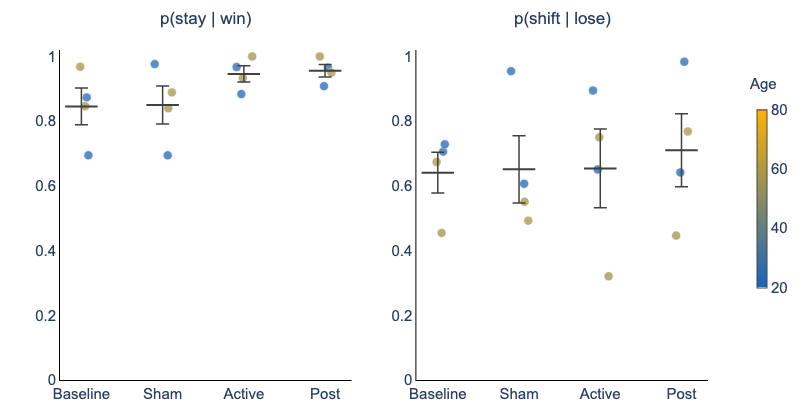

In [153]:
# Visualize WSLS Parameters by Condition (interactive)

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors

# ---- Configuration ----
condition_order = ['baseline', 'sham', 'active', 'post']
age_min, age_max = 20, 80
cap_w = 0.08  # half-width of error bar caps

# Age → color mapping (blue #1565C0 for young, gold #FFB300 for old)
age_cmap = mcolors.LinearSegmentedColormap.from_list(
    'blue_gold', ['#1565C0', '#FFB300']
)
age_lookup = data.groupby('subject_id')['age'].first().to_dict()

def age_to_color(age):
    norm = np.clip((age - age_min) / (age_max - age_min), 0, 1)
    rgba = age_cmap(norm)
    return f'rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})'

# ---- Build figure ----
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=[r'p(stay | win)', r'p(shift | lose)'])

for col, param in enumerate(['p_stay_win', 'p_shift_lose'], start=1):
    plot_data = wsls[wsls['condition'].isin(condition_order)].copy()
    rng = np.random.default_rng(42)

    for i, cond in enumerate(condition_order):
        cond_data = plot_data[plot_data['condition'] == cond]
        jitter = rng.uniform(-0.12, 0.12, size=len(cond_data))

        # Individual data points colored by age
        fig.add_trace(go.Scatter(
            x=i + jitter, y=cond_data[param],
            mode='markers',
            marker=dict(size=9, opacity=0.75,
                        color=[age_to_color(age_lookup.get(s, np.nan)) for s in cond_data['subject_id']],
                        line=dict(width=0.5, color='white')),
            text=[f'sub-{s}<br>Age: {age_lookup.get(s, "?")}'
                  for s in cond_data['subject_id']],
            hoverinfo='text+y', showlegend=False,
        ), row=1, col=col)

        # Mean + SEM with capped error bars
        vals = cond_data[param].dropna()
        if len(vals) > 0:
            mean, sem = vals.mean(), (vals.sem() if len(vals) > 1 else 0)
            for trace_args in [
                dict(x=[i, i], y=[mean - sem, mean + sem]),                    # vertical bar
                dict(x=[i - cap_w, i + cap_w], y=[mean + sem, mean + sem]),    # top cap
                dict(x=[i - cap_w, i + cap_w], y=[mean - sem, mean - sem]),    # bottom cap
            ]:
                fig.add_trace(go.Scatter(
                    **trace_args, mode='lines', line=dict(color='#404040', width=1.5),
                    showlegend=False, hoverinfo='skip',
                ), row=1, col=col)
            # Mean line
            fig.add_trace(go.Scatter(
                x=[i - 0.2, i + 0.2], y=[mean, mean],
                mode='lines', line=dict(color='#404040', width=2),
                showlegend=False, hoverinfo='text',
                text=[f'{cond.capitalize()} mean: {mean:.3f}'] * 2,
            ), row=1, col=col)

    # Per-subplot axis config
    fig.update_xaxes(tickvals=list(range(len(condition_order))),
                     ticktext=[c.capitalize() for c in condition_order], row=1, col=col)
    fig.update_yaxes(range=[0, 1.02], row=1, col=col)

# ---- Layout ----
fig.update_layout(
    height=420, width=800,
    template='plotly_white',
    margin=dict(l=60, r=100, t=50, b=40),
    font=dict(family='Arial', size=14),
)

# ---- Axis styling ----
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=15))
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=15))

# ---- Colorbar (age gradient) ----
dummy_ages = np.linspace(age_min, age_max, 50)
fig.add_trace(go.Scatter(
    x=[None]*50, y=[None]*50, mode='markers',
    marker=dict(size=0.1, color=dummy_ages,
                colorscale=[[0, '#1565C0'], [1, '#FFB300']],
                cmin=age_min, cmax=age_max,
                colorbar=dict(x=1.06, y=0.55, len=0.6, thickness=10,
                              tickfont=dict(size=15))),
    showlegend=False, hoverinfo='skip',
))
fig.add_annotation(text='Age', x=1.11, y=.93, xref='paper', yref='paper',
                   showarrow=False, font=dict(family='Arial', size=15))

# ---- Subplot title styling ----
for ann in fig.layout.annotations:
    if ann.text in [r'p(stay | win)', r'p(shift | lose)']:
        ann.update(font_size=17, y=1.06)

# ---- Show ----
fig.show(config=dict(toImageButtonOptions=dict(filename='wsls_by_condition')))

## 4. Rescorla-Wagner Model Fitting

Fit a simple Rescorla-Wagner model to each subject × condition block. Two free parameters:

- **α** (learning rate): $Q_{c,t+1} = Q_{c,t} + \alpha \left( r_t - Q_{c,t} \right)$, where $r_t \in \{0, 1\}$. Higher α → stronger weighting of recent outcomes; α ≈ 1 reduces to a memoryless (WSLS-like) strategy.
- **β** (inverse temperature): $p(\text{choice} = i) = \frac{e^{\beta \, Q_i}}{\sum_j e^{\beta \, Q_j}}$. Higher β → more deterministic exploitation of learned values; β → 0 → random responding. Also serves as task-derived reward sensitivity (pre-registered).

Values initialized at 0.5 (equal preference). Fitted via MLE with 10 random starts; BIC computed for model comparison. Fits hitting parameter bounds (α ≥ .998, β ≥ 49.9) are flagged — boundary α is common in reversal tasks with short contingency blocks, as rapid updating is adaptive and the single-α model cannot distinguish fast learning from reactive responding.

In [51]:
def rescorla_wagner_nll(params, choices, rewards):
    """
    Negative log-likelihood for a simple Rescorla-Wagner model.
    
    Parameters
    ----------
    params : array [alpha, beta]
        alpha: learning rate (0, 1)
        beta: inverse temperature (0, inf)
    choices : array of int (1 or 2)
        Participant's choice on each trial
    rewards : array of bool
        Whether each trial was rewarded
    
    Returns
    -------
    float : negative log-likelihood
    """
    alpha, beta = params
    
    # Initialize values for both options
    Q = np.array([0.5, 0.5])
    nll = 0.0
    
    for choice, reward in zip(choices, rewards):
        # Softmax choice probability
        exp_vals = np.exp(beta * (Q - np.max(Q)))  # numerically stable softmax
        p = exp_vals / exp_vals.sum()
        
        # Choice index (0-indexed)
        c = int(choice) - 1
        
        # Accumulate log-likelihood (clipped to avoid log(0))
        nll -= np.log(np.clip(p[c], 1e-8, 1.0))
        
        # Update chosen option's value
        r = float(reward)
        Q[c] += alpha * (r - Q[c])
    
    return nll


def fit_rescorla_wagner(choices, rewards, n_starts=10):
    """
    Fit RW model using multiple random starting points.
    
    Returns
    -------
    dict with keys: alpha, beta, nll, bic, converged
    """
    n_trials = len(choices)
    bounds = [(0.001, 0.999), (0.01, 50.0)]  # alpha, beta
    
    best_result = None
    best_nll = np.inf
    
    for _ in range(n_starts):
        # Random initial parameters
        x0 = [np.random.uniform(0.01, 0.99), np.random.uniform(0.1, 10.0)]
        
        result = optimize.minimize(
            rescorla_wagner_nll, x0, args=(choices, rewards),
            bounds=bounds, method='L-BFGS-B'
        )
        
        if result.fun < best_nll:
            best_nll = result.fun
            best_result = result
    
    # BIC = k*ln(n) - 2*ln(L)
    k = 2  # number of free parameters
    bic = k * np.log(n_trials) + 2 * best_nll
    
    # Check for boundary values (convergence failure flag per pre-reg)
    alpha, beta = best_result.x
    at_boundary = (alpha <= 0.002 or alpha >= 0.998 or beta <= 0.02 or beta >= 49.9)
    
    return {
        'alpha': alpha,
        'beta': beta,
        'nll': best_nll,
        'bic': bic,
        'at_boundary': at_boundary,
        'converged': best_result.success
    }

In [53]:
# Fit RW model for each subject x condition
rw_results = []

for (sub_id, condition), group in data.groupby(['subject_id', 'condition']):
    # Drop missed trials
    valid = group.dropna(subset=['choice', 'reward'])
    
    if len(valid) < 10:  # need minimum trials for stable estimation
        print(f'  sub-{sub_id} {condition}: only {len(valid)} valid trials, skipping')
        continue
    
    fit = fit_rescorla_wagner(valid['choice'].values, valid['reward'].values)
    fit['subject_id'] = sub_id
    fit['condition'] = condition
    fit['n_trials'] = len(valid)
    rw_results.append(fit)

rw = pd.DataFrame(rw_results)

print('Rescorla-Wagner parameter estimates:')
print(rw[['subject_id', 'condition', 'alpha', 'beta', 'nll', 'bic', 'at_boundary']]
      .to_string(index=False, float_format='{:.3f}'.format))

# Flag boundary cases
if rw['at_boundary'].any():
    print('\n⚠ WARNING: Some fits hit parameter boundaries (potential convergence failure):')
    print(rw[rw['at_boundary']][['subject_id', 'condition', 'alpha', 'beta']])

Rescorla-Wagner parameter estimates:
subject_id condition  alpha   beta    nll     bic  at_boundary
     10656    active  0.999  3.172 54.401 118.836         True
     10656  baseline  0.966  2.107 68.740 147.391        False
     10656      post  0.927  3.661 54.221 118.463        False
     10656      sham  0.999  3.832 54.953 119.966         True
     10886    active  0.999  2.747 60.338 130.724         True
     10886  baseline  0.987  3.183 50.081 110.116        False
     10886      post  0.940  3.144 63.109 136.253        False
     10886      sham  0.432  2.763 72.534 155.089        False
     10998    active  0.712  2.510 73.534 157.102        False
     10998  baseline  0.861  1.424 87.123 184.199        False
     10998      post  0.810  2.331 70.093 150.247        False
     10998      sham  0.368  1.583 89.060 188.003        False
     11773    active  0.890  6.269 38.028  86.220        False
     11773  baseline  0.232  3.682 78.559 167.125        False
     11773      po

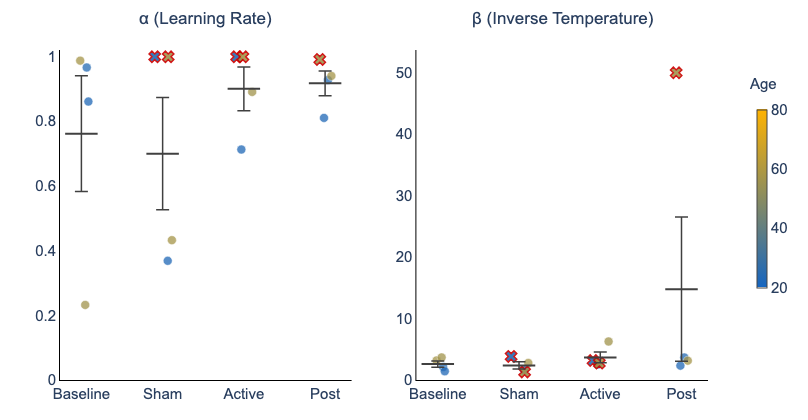

In [147]:
# Visualize Rescorla-Wagner Parameters by Condition (interactive)

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors

# ---- Configuration ----
condition_order = ['baseline', 'sham', 'active', 'post']
age_min, age_max = 20, 80
cap_w = 0.08  # half-width of error bar caps

# Age → color mapping (blue #1565C0 for young, gold #FFB300 for old)
age_cmap = mcolors.LinearSegmentedColormap.from_list(
    'blue_gold', ['#1565C0', '#FFB300']
)
age_lookup = data.groupby('subject_id')['age'].first().to_dict()

def age_to_color(age):
    norm = np.clip((age - age_min) / (age_max - age_min), 0, 1)
    rgba = age_cmap(norm)
    return f'rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})'

# ---- Build figure ----
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=[r'α (Learning Rate)', r'β (Inverse Temperature)'])

for col, (param, ylim) in enumerate([('alpha', [0, 1.02]), ('beta', None)], start=1):
    plot_data = rw[rw['condition'].isin(condition_order)].copy()
    rng = np.random.default_rng(42)

    for i, cond in enumerate(condition_order):
        cond_data = plot_data[plot_data['condition'] == cond]
        jitter = rng.uniform(-0.12, 0.12, size=len(cond_data))
        boundary_mask = cond_data['at_boundary'].values

        # Hover text (shared format for both normal and boundary points)
        def make_hover(sub_df):
            return [f'sub-{s}<br>Age: {age_lookup.get(s, "?")}<br>α={r["alpha"]:.3f}, β={r["beta"]:.2f}'
                    for s, (_, r) in zip(sub_df['subject_id'], sub_df.iterrows())]

        # Normal points
        normal = cond_data[~cond_data['at_boundary']]
        if len(normal) > 0:
            fig.add_trace(go.Scatter(
                x=i + jitter[~boundary_mask], y=normal[param],
                mode='markers',
                marker=dict(size=9, opacity=0.75,
                            color=[age_to_color(age_lookup.get(s, np.nan)) for s in normal['subject_id']],
                            line=dict(width=0.5, color='white')),
                text=make_hover(normal), hoverinfo='text', showlegend=False,
            ), row=1, col=col)

        # Boundary fits (X marker with red outline)
        boundary = cond_data[cond_data['at_boundary']]
        if len(boundary) > 0:
            fig.add_trace(go.Scatter(
                x=i + jitter[boundary_mask], y=boundary[param],
                mode='markers',
                marker=dict(size=10, symbol='x', opacity=0.9,
                            color=[age_to_color(age_lookup.get(s, np.nan)) for s in boundary['subject_id']],
                            line=dict(width=1.5, color='#CC0000')),
                text=[t.replace('sub-', 'sub-') .replace('<br>', ' ⚠ BOUNDARY<br>', 1)
                      for t in make_hover(boundary)],
                hoverinfo='text', showlegend=False,
            ), row=1, col=col)

        # Mean + SEM with capped error bars
        vals = cond_data[param].dropna()
        if len(vals) > 0:
            mean, sem = vals.mean(), (vals.sem() if len(vals) > 1 else 0)
            for trace_args in [
                dict(x=[i, i], y=[mean - sem, mean + sem]),                    # vertical bar
                dict(x=[i - cap_w, i + cap_w], y=[mean + sem, mean + sem]),    # top cap
                dict(x=[i - cap_w, i + cap_w], y=[mean - sem, mean - sem]),    # bottom cap
            ]:
                fig.add_trace(go.Scatter(
                    **trace_args, mode='lines', line=dict(color='#404040', width=1.5),
                    showlegend=False, hoverinfo='skip',
                ), row=1, col=col)
            # Mean line
            fig.add_trace(go.Scatter(
                x=[i - 0.2, i + 0.2], y=[mean, mean],
                mode='lines', line=dict(color='#404040', width=2),
                showlegend=False, hoverinfo='text',
                text=[f'{cond.capitalize()} mean: {mean:.3f}'] * 2,
            ), row=1, col=col)

    # Per-subplot axis config
    fig.update_xaxes(tickvals=list(range(len(condition_order))),
                     ticktext=[c.capitalize() for c in condition_order], row=1, col=col)
    if ylim:
        fig.update_yaxes(range=ylim, row=1, col=col)

# ---- Layout ----
fig.update_layout(
    height=420, width=800,
    template='plotly_white',
    margin=dict(l=60, r=100, t=50, b=40),
    font=dict(family='Arial', size=14),
)

# ---- Axis styling ----
fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=15))
fig.update_yaxes(showgrid=False, rangemode='tozero',
                 showline=True, linewidth=1, linecolor='black',
                 tickfont=dict(size=15))

# ---- Colorbar (age gradient) ----
dummy_ages = np.linspace(age_min, age_max, 50)
fig.add_trace(go.Scatter(
    x=[None]*50, y=[None]*50, mode='markers',
    marker=dict(size=0.1, color=dummy_ages,
                colorscale=[[0, '#1565C0'], [1, '#FFB300']],
                cmin=age_min, cmax=age_max,
                colorbar=dict(x=1.06, y=0.55, len=0.6, thickness=10,
                              tickfont=dict(size=15))),
    showlegend=False, hoverinfo='skip',
))
fig.add_annotation(text='Age', x=1.11, y=.93, xref='paper', yref='paper',
                   showarrow=False, font=dict(family='Arial', size=15))

# ---- Subplot title styling ----
for ann in fig.layout.annotations:
    if ann.text in [r'α (Learning Rate)', r'β (Inverse Temperature)']:
        ann.update(font_size=17, y=1.06)

# ---- Show ----
fig.show(config=dict(toImageButtonOptions=dict(filename='rw_params_by_condition')))

### Parameter Details

**Value update (learning):**

$$Q_{c,t+1} = Q_{c,t} + \alpha \left( r_t - Q_{c,t} \right)$$

| Variable | Meaning |
|----------|---------|
| $Q_{c,t}$ | Estimated value of chosen option $c$ on trial $t$ |
| $r_t$ | Outcome on trial $t$ (1 = reward, 0 = no reward) |
| $r_t - Q_{c,t}$ | **Prediction error** — difference between expected and actual outcome |
| $\alpha \in (0, 1)$ | **Learning rate** — scales how much each prediction error updates the value estimate. Low α → slow, stable learning across many trials. High α → volatile, recent-outcome-driven. At α ≈ 1, the model reduces to a memoryless strategy where $Q_{c,t+1} \approx r_t$. |

Only the chosen option is updated; the unchosen option retains its value.

**Choice rule (softmax):**

$$p(\text{choose } i) = \frac{e^{\beta \, Q_i}}{\sum_j e^{\beta \, Q_j}}$$

| Variable | Meaning |
|----------|---------|
| $Q_i, Q_j$ | Current value estimates for each option |
| $\beta \geq 0$ | **Inverse temperature** — controls the determinism of choice. β → 0: choices are random regardless of values. β → ∞: always choose the highest-valued option. Also serves as task-derived **reward sensitivity** in our pre-registered analyses — higher β reflects stronger behavioral coupling to learned reward values. |

**Model fitting:** Parameters are estimated by minimizing negative log-likelihood across all trials within a subject × condition block, using L-BFGS-B with 10 random restarts. Model comparison uses BIC = $k \ln(n) + 2 \cdot \text{NLL}$, where $k = 2$ free parameters.